# Thesis Experiment: RL-Based Gamma Controller (Weekly Rebalancing)
**Setup:** 7-Day Rebalancing Frequency for realistic portfolio management.

---

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from scipy.optimize import minimize
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded.")

Libraries loaded.


## Phase 1: Data Preparation

In [10]:
file_old = 'crypto_data_real.xlsx'
file_2024 = 'crypto_data_2024.xlsx'

def load_and_preprocess(f1, f2):
    r_old = pd.read_excel(f1, sheet_name='Returns', index_col=0)
    r_2024 = pd.read_excel(f2, sheet_name='Returns', index_col=0)
    r_old.index = pd.to_datetime(r_old.index)
    r_2024.index = pd.to_datetime(r_2024.index)
    assets = list(set(r_old.columns) & set(r_2024.columns))
    assets.sort()
    return r_old[assets], r_2024[assets], assets

ret_old, ret_2024, assets = load_and_preprocess(file_old, file_2024)
print(f"Data loaded. Assets: {len(assets)}")

Data loaded. Assets: 10


## Phase 2: Core Functions

In [11]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1/Q))**2
    
    # Filter: Set non-significant eigenvalues to 0 (RMT Standard)
    # Sesuai Giudici (2020), hanya deviating eigenvalues yang dipertahankan
    eigenvalues[eigenvalues < lambda_max] = 0
    
    # Reconstruction
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised

def get_centrality_weights(returns_window, gamma=1.0):
    """
    Computes Network-Regularized Markowitz weights as per Giudici et al (2020):
    1. RMT Filter
    2. MST Reduction (Langkah krusial paper)
    3. Eigenvector Centrality from MST structure
    4. Optimization: w' * Sigma * w + gamma * (centrality' * w)
    """
    T, N = returns_window.shape
    mu = returns_window.mean().values
    sigma = returns_window.std().values
    
    # 1. Denoised Covariance Matrix (RMT)
    corr_f = apply_rmt_filter(returns_window)
    cov_f = np.outer(sigma, sigma) * corr_f
    cov_f += np.eye(N) * 1e-8 # Numerical stability
    
    # 2. MST Reduction (Giudici Step)
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    
    # 3. Centrality calculation from MST
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))

    # 4. Optimization
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    
    # Constraint 1: bobot harus sum=1
    # Constraint 2: return portofolio >= rata-rata return (mencegah dominasi stablecoin)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    # Bound 0.1 as per paper for crypto portfolios
    bnds = tuple((0, 0.4) for _ in range(N))
    x0 = np.ones(N) / N
    
    res = minimize(fun, x0, method='SLSQP', bounds=bnds, constraints=cons)
    
    if not res.success:
        return np.ones(N) / N
        
    return res.x

class PortfolioStrategy:
    def __init__(self, name): 
        self.name = name
        self.last_gamma = 1.0
    def compute_weights(self, returns_window): raise NotImplementedError()
    
class EquallyWeighted(PortfolioStrategy):
    def compute_weights(self, returns_window): return np.ones(returns_window.shape[1])/returns_window.shape[1]
class ClassicalMarkowitz(PortfolioStrategy):
    def compute_weights(self, returns_window):
        cov = returns_window.cov().values
        inv_cov = np.linalg.pinv(cov)
        w = np.clip(inv_cov @ np.ones(cov.shape[0]), 0, 1)
        return w / np.sum(w)
class NetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name, gamma=1.0):
        super().__init__(name)
        self.gamma = gamma
    def compute_weights(self, returns_window): return get_centrality_weights(returns_window, self.gamma)


## Phase 3: RL Agent

In [12]:
class GammaPortfolioEnv(gym.Env):
    def __init__(self, returns_data, window_size=120, reward_mode='sharpe'):
        super().__init__()
        self.data = returns_data
        self.window_size = window_size
        self.reward_mode = reward_mode
        self.current_step = window_size
        self.action_space = spaces.Box(low=0.0, high=10.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(4,), dtype=np.float32)
        self.port_val = 1.0
        self.peak_val = 1.0
        
    def _get_obs(self):
        win = self.data.iloc[self.current_step - self.window_size : self.current_step]
        # FEATURE SCALING: Multiply small values to improve PPO gradient stability
        m = win.mean().mean() * 100
        s = win.std().mean() * 100
        c = win.corr().values.mean()
        st_c = np.std(get_centrality_weights(win)) * 10
        return np.array([m, s, c, st_c], dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.port_val = 1.0
        self.peak_val = 1.0
        return self._get_obs(), {}
        
    def step(self, action):
        win = self.data.iloc[self.current_step - self.window_size : self.current_step]
        w = get_centrality_weights(win, float(action[0]))
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)
        
        self.port_val *= (1 + port_ret)
        self.peak_val = max(self.peak_val, self.port_val)
        drawdown = (self.port_val - self.peak_val) / self.peak_val
        ew_ret = self.data.iloc[self.current_step].mean()
        
        if self.reward_mode == 'raw_return': reward = port_ret
        elif self.reward_mode == 'excess_return': reward = port_ret - ew_ret
        elif self.reward_mode == 'defensive': reward = port_ret - 2.0 * abs(drawdown)
        else: reward = port_ret / (win.values.std() + 1e-6)
            
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        return self._get_obs(), reward, done, False, {}

class RLNetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name, model_path):
        super().__init__(name)
        self.model = PPO.load(model_path)
    def compute_weights(self, returns_window):
        # MUST USE SAME SCALING AS IN ENV
        m = returns_window.mean().mean() * 100
        s = returns_window.std().mean() * 100
        c = returns_window.corr().values.mean()
        st_c = np.std(get_centrality_weights(returns_window)) * 10
        obs = np.array([m, s, c, st_c], dtype=np.float32)
        action, _ = self.model.predict(obs, deterministic=True)
        self.last_gamma = float(action[0])
        return get_centrality_weights(returns_window, gamma=self.last_gamma)

## Phase 4: Backtest Engine (Fixed Frequency Rebalancing)

In [13]:
def run_backtest_with_frequency(strategy, data, window=120, rebalance_freq=7):
    rets = []
    dates = []
    weights_history = []
    gamma_history = []
    
    current_weights = None
    current_gamma = 1.0
    
    print(f"Processing {strategy.name} (Freq: {rebalance_freq} days)...")
    for i in range(window, len(data)):
        # REBALANCE ONLY EVERY 'rebalance_freq' DAYS
        if (i - window) % rebalance_freq == 0:
            window_df = data.iloc[i-window : i]
            current_weights = strategy.compute_weights(window_df)
            current_gamma = getattr(strategy, 'last_gamma', 1.0)
        
        # DAILY RETURN CALCULATION
        r = np.dot(current_weights, data.iloc[i].values)
        rets.append(r)
        dates.append(data.index[i])
        weights_history.append(current_weights)
        gamma_history.append(current_gamma)
        
    return pd.Series(rets, index=dates), pd.DataFrame(weights_history, index=dates, columns=data.columns), pd.Series(gamma_history, index=dates)

def calculate_metrics(r):
    cr = (1+r).cumprod()
    sharpe = (np.mean(r)/np.std(r))*np.sqrt(252)
    mdd = ((cr/cr.expanding().max())-1).min()
    return {"Total Return": f"{cr.iloc[-1]-1:.2%}", "Sharpe": f"{sharpe:.2f}", "MDD": f"{mdd:.2%}"}

## Phase 5: Comparative Analysis (7-Day Rebalancing)

Training RL models (5,000 steps)...


RL-Net (Defensive):   0%|          | 0/5000 [00:00<?, ?it/s]

RL-Net (Total Return):   0%|          | 0/5000 [00:00<?, ?it/s]

Processing NW (Gamma=1.0) (Freq: 7 days)...
Processing RL-Net (Defensive) (Freq: 7 days)...
Processing RL-Net (Total Return) (Freq: 7 days)...


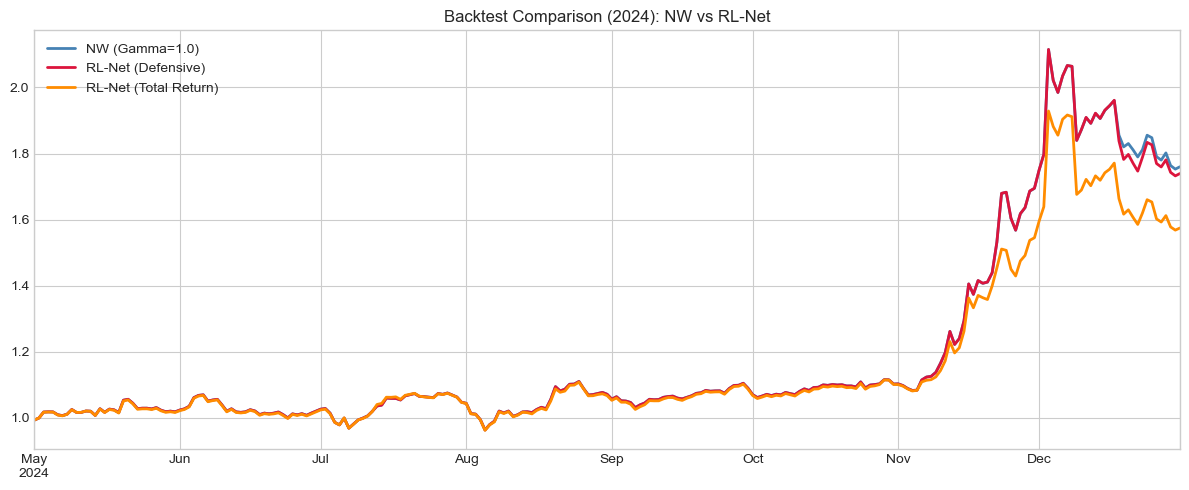

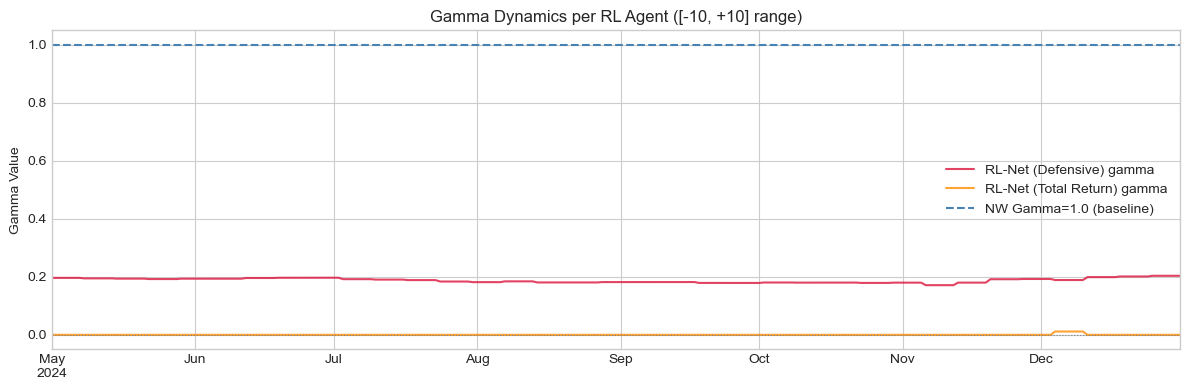

=== Performance Metrics ===
                      Total Return Sharpe      MDD
Strategy                                          
NW (Gamma=1.0)              76.01%   1.89  -17.11%
RL-Net (Defensive)          73.95%   1.84  -18.09%
RL-Net (Total Return)       57.47%   1.61  -18.69%

CSV saved to: backtest_results/


In [14]:
from tqdm.notebook import tqdm
from stable_baselines3.common.callbacks import BaseCallback
import os

# === Custom Progress Bar Callback ===
class TqdmCallback(BaseCallback):
    def __init__(self, total_timesteps, desc='Training'):
        super().__init__()
        self.pbar = None
        self.total_timesteps = total_timesteps
        self.desc = desc

    def _on_training_start(self):
        self.pbar = tqdm(total=self.total_timesteps, desc=self.desc)

    def _on_step(self):
        self.pbar.update(1)
        return True

    def _on_training_end(self):
        if self.pbar: self.pbar.close()

# ===================================================================
# KONFIGURASI — ubah STEPS ke 50000 untuk thesis final
# ===================================================================
SET_WINDOW    = 120
SET_REBALANCE = 7
STEPS         = 5000   # <-- 5k untuk test cepat; naikkan ke 50000 untuk thesis
train_data = ret_old.iloc[:int(len(ret_old)*0.8)]

def train_optimized_model(env, name, desc='Training'):
    model = PPO(
        'MlpPolicy', env,
        learning_rate=0.0001,
        n_steps=2048,
        batch_size=64,
        ent_coef=0.01,
        verbose=0
    )
    model.learn(total_timesteps=STEPS, callback=TqdmCallback(STEPS, desc=desc))
    model.save(name)
    return model

# === Training: 2 model ===
print(f'Training RL models ({STEPS:,} steps)...')
train_optimized_model(
    GammaPortfolioEnv(train_data, reward_mode='defensive'),
    'final_mdd',
    'RL-Net (Defensive)'
)
train_optimized_model(
    GammaPortfolioEnv(train_data, reward_mode='raw_return'),
    'final_raw',
    'RL-Net (Total Return)'
)

# === Backtest — 3 strategi ===
strategies = [
    NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0),
    NetworkMarkowitz('NW (Gamma=0.0)', gamma=0.0),
    RLNetworkMarkowitz('RL-Net (Defensive)',    'final_mdd'),
    RLNetworkMarkowitz('RL-Net (Total Return)', 'final_raw'),
]

results_map = {}
gamma_map   = {}
for s in strategies:
    res, _, g_hist = run_backtest_with_frequency(
        s, ret_2024, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
    )
    results_map[s.name] = res
    if 'RL-Net' in s.name:
        gamma_map[s.name] = g_hist

# === Plot 1: Cumulative Returns ===
colors = {
    'NW (Gamma=1.0)':       'steelblue',
    'NW (Gamma=0.0)':       'gray',
    'RL-Net (Defensive)':    'crimson',
    'RL-Net (Total Return)': 'darkorange',
}
plt.figure(figsize=(12, 5))
for name, r in results_map.items():
    (1 + r).cumprod().plot(
        label=name,
        color=colors.get(name),
        linewidth=2.0
    )
plt.title('Backtest Comparison (2024): NW vs RL-Net')
plt.legend()
plt.tight_layout()
plt.show()

# === Plot 2: Gamma Dynamics RL ===
if gamma_map:
    plt.figure(figsize=(12, 4))
    for name, g in gamma_map.items():
        g.plot(label=f'{name} gamma', color=colors.get(name), alpha=0.8)
    plt.axhline(1.0, color='steelblue', linestyle='--', label='NW Gamma=1.0 (baseline)')
    plt.axhline(0.0, color='gray', linestyle=':', linewidth=0.8)
    plt.title('Gamma Dynamics per RL Agent ([-10, +10] range)')
    plt.ylabel('Gamma Value')
    plt.legend()
    plt.tight_layout()
    plt.show()

# === Simpan Data ke CSV ===
csv_dir = 'backtest_results'
os.makedirs(csv_dir, exist_ok=True)

cumret_df = pd.DataFrame({name: (1 + r).cumprod() for name, r in results_map.items()})
cumret_df.index.name = 'Date'
cumret_df.to_csv(os.path.join(csv_dir, 'cumulative_returns.csv'))

dailyret_df = pd.DataFrame(results_map)
dailyret_df.index.name = 'Date'
dailyret_df.to_csv(os.path.join(csv_dir, 'daily_returns.csv'))

if gamma_map:
    gamma_df = pd.DataFrame(gamma_map)
    gamma_df.index.name = 'Date'
    gamma_df.to_csv(os.path.join(csv_dir, 'gamma_dynamics.csv'))

stats = pd.DataFrame({name: calculate_metrics(r) for name, r in results_map.items()}).T
stats.index.name = 'Strategy'
stats.to_csv(os.path.join(csv_dir, 'performance_metrics.csv'))

print('=== Performance Metrics ===')
print(stats.to_string())
print(f'\nCSV saved to: {csv_dir}/')


## Phase 6: In-Sample Backtest (Training Data)
Backtesting the trained RL models on the **training period** to assess in-sample fit and compare against the NW baseline.

Processing NW (Gamma=1.0) (Freq: 7 days)...
Processing RL-Net (Defensive) (Freq: 7 days)...
Processing RL-Net (Total Return) (Freq: 7 days)...


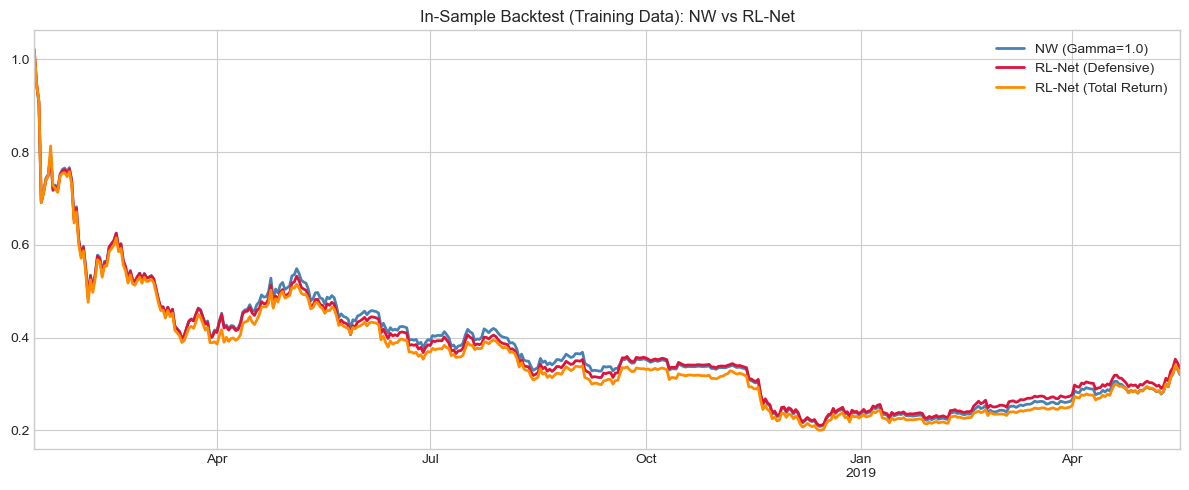

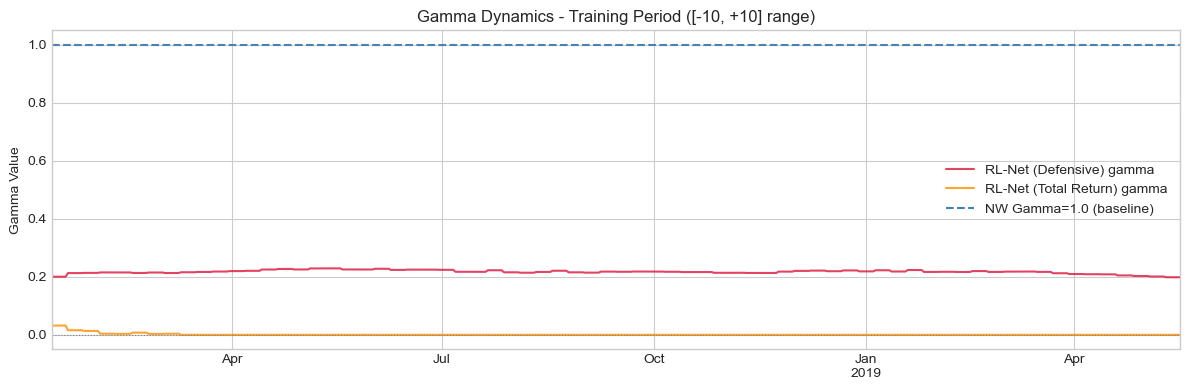

=== In-Sample Performance Metrics (Training Data) ===
                      Total Return Sharpe      MDD
Strategy                                          
NW (Gamma=1.0)             -68.03%  -0.99  -79.47%
RL-Net (Defensive)         -66.65%  -0.93  -79.35%
RL-Net (Total Return)      -67.83%  -0.97  -80.39%

CSV saved to: backtest_results/


In [15]:
# ============================================================
# Phase 6: In-Sample Backtest on Training Data
# ============================================================
# Gunakan model yang sudah di-train di Phase 5; jalankan backtest
# pada train_data (80% pertama dari ret_old) untuk melihat in-sample fit.

strategies_insample = [
    NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0),
    NetworkMarkowitz('NW (Gamma=0.0)', gamma=0.0),
    RLNetworkMarkowitz('RL-Net (Defensive)',    'final_mdd'),
    RLNetworkMarkowitz('RL-Net (Total Return)', 'final_raw'),
]

results_map_train = {}
gamma_map_train   = {}
for s in strategies_insample:
    res, _, g_hist = run_backtest_with_frequency(
        s, train_data, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
    )
    results_map_train[s.name] = res
    if 'RL-Net' in s.name:
        gamma_map_train[s.name] = g_hist

# === Plot 1: Cumulative Returns (Training) ===
colors = {
    'NW (Gamma=1.0)':       'steelblue',
    'NW (Gamma=0.0)':       'gray',
    'RL-Net (Defensive)':    'crimson',
    'RL-Net (Total Return)': 'darkorange',
}
plt.figure(figsize=(12, 5))
for name, r in results_map_train.items():
    (1 + r).cumprod().plot(
        label=name,
        color=colors.get(name),
        linewidth=2.0
    )
plt.title('In-Sample Backtest (Training Data): NW vs RL-Net')
plt.legend()
plt.tight_layout()
plt.show()

# === Plot 2: Gamma Dynamics RL (Training) ===
if gamma_map_train:
    plt.figure(figsize=(12, 4))
    for name, g in gamma_map_train.items():
        g.plot(label=f'{name} gamma', color=colors.get(name), alpha=0.8)
    plt.axhline(1.0, color='steelblue', linestyle='--', label='NW Gamma=1.0 (baseline)')
    plt.axhline(0.0, color='gray', linestyle=':', linewidth=0.8)
    plt.title('Gamma Dynamics - Training Period ([-10, +10] range)')
    plt.ylabel('Gamma Value')
    plt.legend()
    plt.tight_layout()
    plt.show()

# === Simpan Data Training ke CSV ===
csv_dir = 'backtest_results'
os.makedirs(csv_dir, exist_ok=True)

cumret_train_df = pd.DataFrame({name: (1 + r).cumprod() for name, r in results_map_train.items()})
cumret_train_df.index.name = 'Date'
cumret_train_df.to_csv(os.path.join(csv_dir, 'training_cumulative_returns.csv'))

dailyret_train_df = pd.DataFrame(results_map_train)
dailyret_train_df.index.name = 'Date'
dailyret_train_df.to_csv(os.path.join(csv_dir, 'training_daily_returns.csv'))

if gamma_map_train:
    gamma_train_df = pd.DataFrame(gamma_map_train)
    gamma_train_df.index.name = 'Date'
    gamma_train_df.to_csv(os.path.join(csv_dir, 'training_gamma_dynamics.csv'))

stats_train = pd.DataFrame({name: calculate_metrics(r) for name, r in results_map_train.items()}).T
stats_train.index.name = 'Strategy'
stats_train.to_csv(os.path.join(csv_dir, 'training_performance_metrics.csv'))

print('=== In-Sample Performance Metrics (Training Data) ===')
print(stats_train.to_string())
print(f'\nCSV saved to: {csv_dir}/')


## Phase 7: Diagnostic – Weight Concentration Analysis (Training Data)
Analisis mengapa NW (Gamma=1.0) sangat stabil pada training data.
Kita periksa apakah portfolio terkonsentrasi pada aset yang harganya stabil (misal USDT/stablecoin).

Processing NW (Gamma=1.0) (Freq: 7 days)...
=== Rata-rata Bobot NW (Gamma=1.0) — Training Data ===
USDT    0.395268
BTC     0.182623
BNB     0.118236
XLM     0.074976
LTC     0.062175
XRP     0.049062
TRX     0.044568
ETH     0.042200
EOS     0.026600
BCH     0.004291


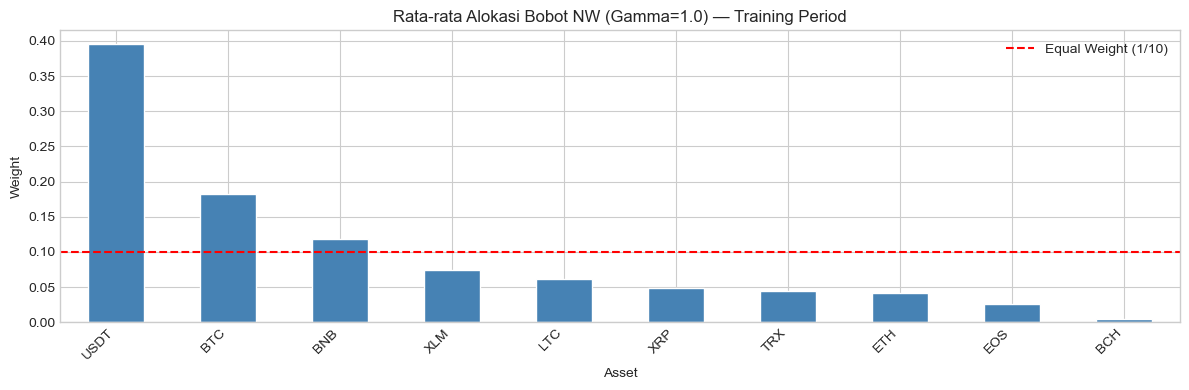

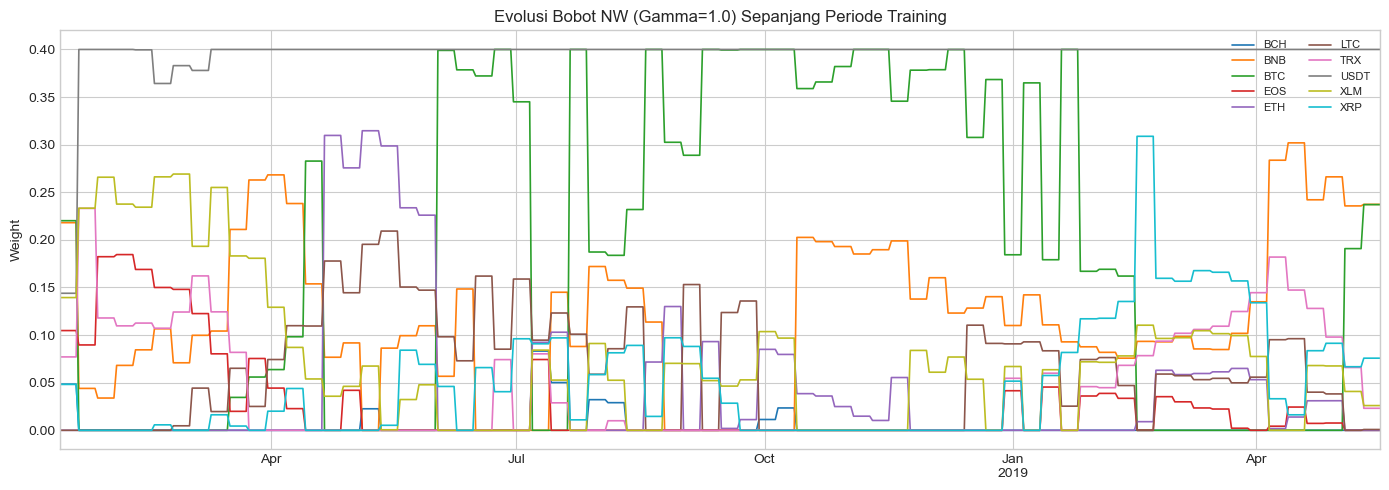


=== Jumlah Hari Bobot Aset > 30% ===
USDT    483
BTC     182
ETH      14
BNB       7
XRP       7

=== Statistik Aset vs Bobot (sorted by Volatility) ===
      Mean Daily Return  Std (Volatility)  Mean Weight
USDT          -0.000019          0.005971     0.395268
BTC            0.001385          0.043990     0.182623
ETH           -0.000451          0.052354     0.042200
LTC            0.001247          0.061116     0.062175
BNB            0.004192          0.066384     0.118236
XLM            0.001890          0.069713     0.074976
XRP            0.000941          0.070600     0.049062
EOS            0.002671          0.074644     0.026600
BCH           -0.000958          0.077146     0.004291
TRX            0.004020          0.094293     0.044568


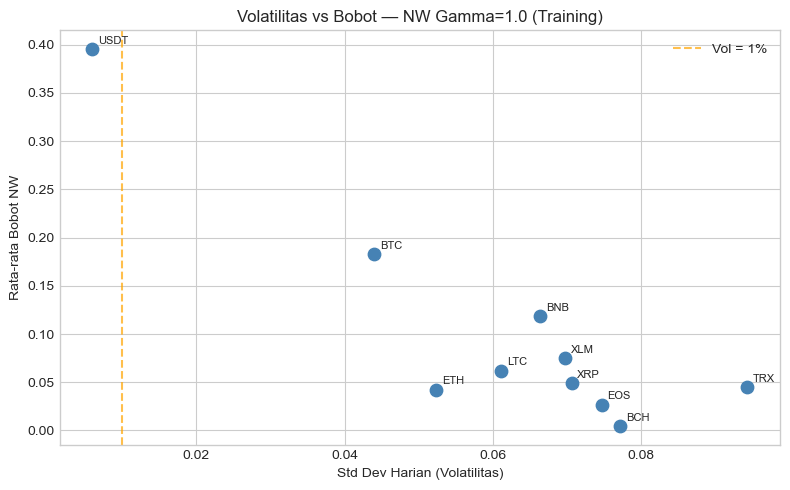


=== Korelasi Aset vs Return NW ===
BTC     0.893755
ETH     0.856824
XLM     0.846888
BNB     0.833117
LTC     0.832891
XRP     0.804395
TRX     0.787321
EOS     0.777484
BCH     0.760974
USDT    0.064814


In [16]:
# ============================================================
# Phase 7: Weight Concentration Diagnostic
# ============================================================

# Re-run backtest NW dengan menyimpan history bobot
nw_strat = NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0)
nw_ret_train, nw_wts_train, _ = run_backtest_with_frequency(
    nw_strat, train_data, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
)

# ── 1. Rata-rata bobot per aset (training period) ──────────────
mean_wts = nw_wts_train.mean().sort_values(ascending=False)
print("=== Rata-rata Bobot NW (Gamma=1.0) — Training Data ===")
print(mean_wts.to_string())

# ── 2. Bar-chart bobot rata-rata ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
mean_wts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Rata-rata Alokasi Bobot NW (Gamma=1.0) — Training Period")
ax.set_ylabel("Weight")
ax.set_xlabel("Asset")
ax.axhline(1/len(assets), color="red", linestyle="--", label=f"Equal Weight (1/{len(assets)})")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ── 3. Time-series bobot per aset ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
nw_wts_train.plot(ax=ax, linewidth=1.2)
ax.set_title("Evolusi Bobot NW (Gamma=1.0) Sepanjang Periode Training")
ax.set_ylabel("Weight")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# ── 4. Deteksi asset dominan (threshold >30%) ─────────────────
dominant_threshold = 0.30
dominant_days = (nw_wts_train > dominant_threshold).sum()
print("\n=== Jumlah Hari Bobot Aset > 30% ===")
print(dominant_days[dominant_days > 0].sort_values(ascending=False).to_string())

# ── 5. Volatilitas (std) dan mean return per aset ─────────────
asset_stats = pd.DataFrame({
    "Mean Daily Return": train_data.mean(),
    "Std (Volatility)":  train_data.std(),
    "Mean Weight":       mean_wts,
}).sort_values("Std (Volatility)")
print("\n=== Statistik Aset vs Bobot (sorted by Volatility) ===")
print(asset_stats.round(6).to_string())

# ── 6. Scatter: volatilitas vs bobot rata-rata ────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(asset_stats["Std (Volatility)"], asset_stats["Mean Weight"], s=80, color="steelblue")
for idx, row in asset_stats.iterrows():
    ax.annotate(idx, (row["Std (Volatility)"], row["Mean Weight"]),
                textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.set_xlabel("Std Dev Harian (Volatilitas)")
ax.set_ylabel("Rata-rata Bobot NW")
ax.set_title("Volatilitas vs Bobot — NW Gamma=1.0 (Training)")
ax.axvline(0.01, color="orange", linestyle="--", alpha=0.7, label="Vol = 1%")
ax.legend()
plt.tight_layout()
plt.show()

# ── 7. Korelasi aset dengan NW return ────────────────────────
corr_with_nw = train_data.corrwith(nw_ret_train).sort_values(ascending=False)
print("\n=== Korelasi Aset vs Return NW ===")
print(corr_with_nw.to_string())
